In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
df = pd.read_csv("C:\\Users\\Hp\\Downloads\\archive (1)\\customer_segmentation_data.csv")
df

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08
...,...,...,...,...,...,...,...,...,...
995,996,57,Male,112170,57,6,1,Clothing,313.64
996,997,23,Other,65337,76,10,23,Groceries,632.83
997,998,23,Male,113097,40,5,42,Sports,75.09
998,999,22,Female,113695,63,7,44,Electronics,505.16


In [2]:
df.shape

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   age                   1000 non-null   int64  
 2   gender                1000 non-null   object 
 3   income                1000 non-null   int64  
 4   spending_score        1000 non-null   int64  
 5   membership_years      1000 non-null   int64  
 6   purchase_frequency    1000 non-null   int64  
 7   preferred_category    1000 non-null   object 
 8   last_purchase_amount  1000 non-null   float64
dtypes: float64(1), int64(6), object(2)
memory usage: 70.4+ KB


In [3]:
df.isnull().sum()



id                      0
age                     0
gender                  0
income                  0
spending_score          0
membership_years        0
purchase_frequency      0
preferred_category      0
last_purchase_amount    0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isna().sum()

id                      0
age                     0
gender                  0
income                  0
spending_score          0
membership_years        0
purchase_frequency      0
preferred_category      0
last_purchase_amount    0
dtype: int64

In [6]:
df.describe()

,id,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,43.783000,88500.800000,50.685000,5.46900,26.596000,492.348670
std,288.819436,15.042213,34230.771122,28.955175,2.85573,14.243654,295.744253
min,1.000000,18.000000,30004.000000,1.000000,1.00000,1.000000,10.400000
25%,250.750000,30.000000,57911.750000,26.000000,3.00000,15.000000,218.762500
50%,500.500000,45.000000,87845.500000,50.000000,5.00000,27.000000,491.595000
75%,750.250000,57.000000,116110.250000,76.000000,8.00000,39.000000,747.170000
max,1000.000000,69.000000,149973.000000,100.000000,10.00000,50.000000,999.740000


In [7]:
bins = [0, 18, 25, 45, 60, 100]  # Adjusted age ranges based on your request
labels = ['Under 18', '18-25', '25-45', '45-60', '60 and Above']

# Create New Column for Age Groups
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

df.head(20)

df = df.drop(columns=['id','age'])




Text(0.5, 1.0, 'last_purchase_amount')

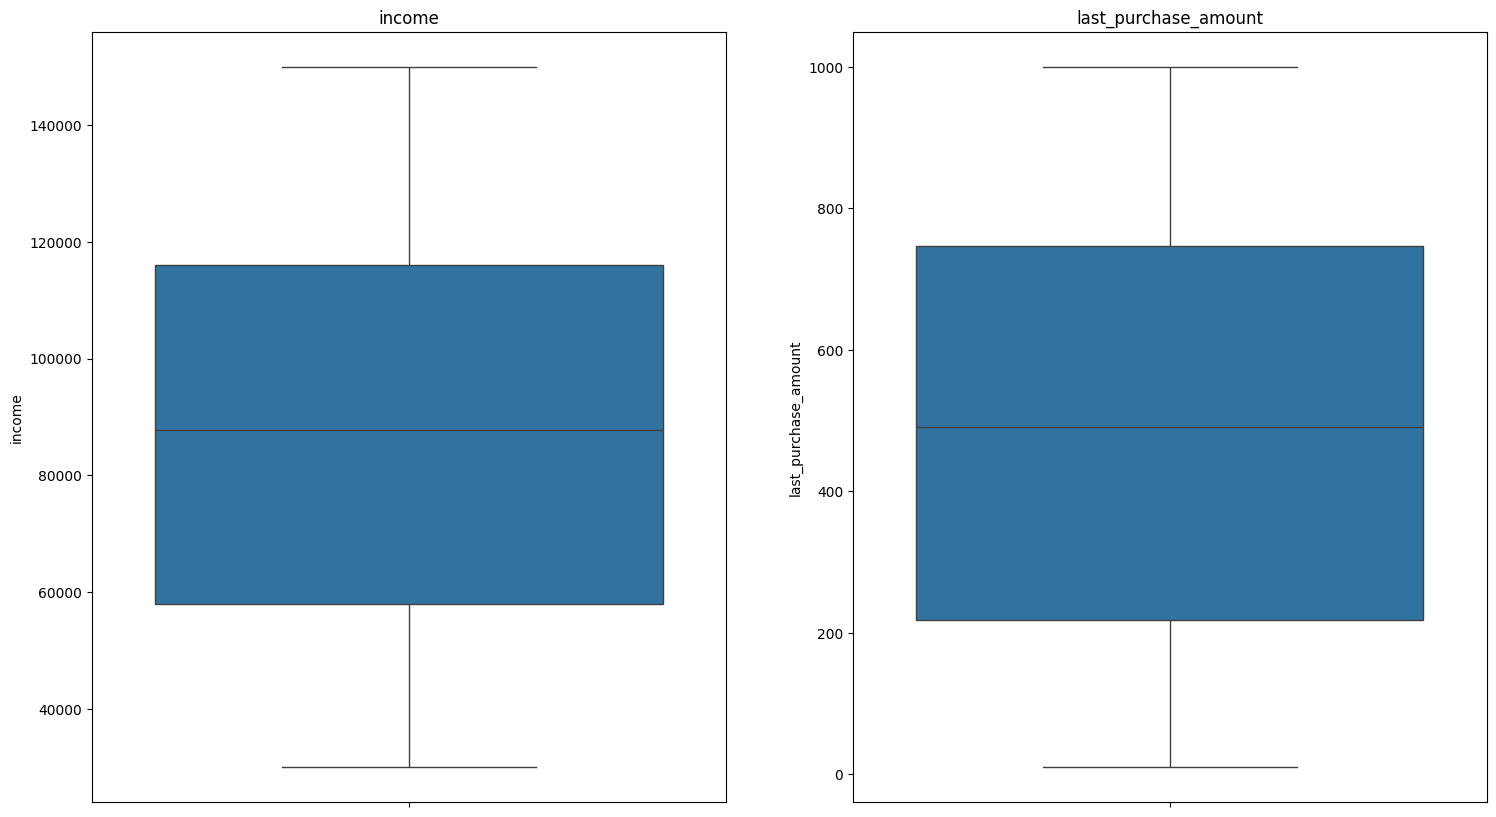

In [8]:
plt.figure(figsize=(18,10))

plt.subplot(1,2,1)
sns.boxplot(df['income'])
plt.title("income")

plt.subplot(1,2,2)
sns.boxplot(df['last_purchase_amount'])
plt.title("last_purchase_amount")

In [9]:
df

,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount,age_group
0,Female,99342,90,3,24,Groceries,113.53,25-45
1,Female,78852,60,2,42,Sports,41.93,18-25
2,Female,126573,30,2,28,Clothing,424.36,60 and Above
3,Other,47099,74,9,5,Home & Garden,991.93,25-45
4,Female,140621,21,3,25,Electronics,347.08,60 and Above
...,...,...,...,...,...,...,...,...
995,Male,112170,57,6,1,Clothing,313.64,45-60
996,Other,65337,76,10,23,Groceries,632.83,18-25
997,Male,113097,40,5,42,Sports,75.09,18-25
998,Female,113695,63,7,44,Electronics,505.16,18-25


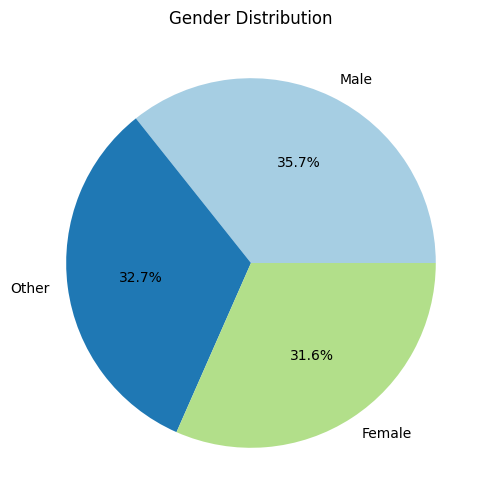

In [10]:
plt.figure(figsize=(6,6))
df['gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=plt.cm.Paired.colors)
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

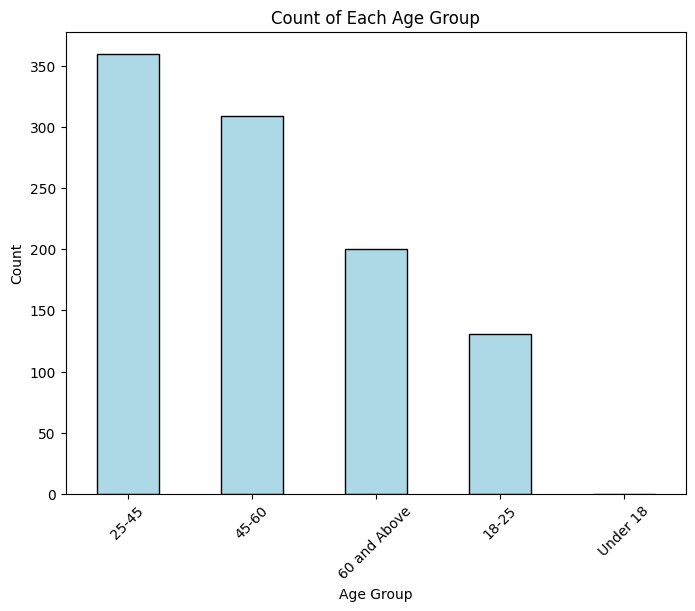

In [11]:
plt.figure(figsize=(8,6))
df['age_group'].value_counts().plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Count of Each Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_17628\1083770825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['preferred_category'], palette='viridis', order=df['preferred_category'].value_counts().index)


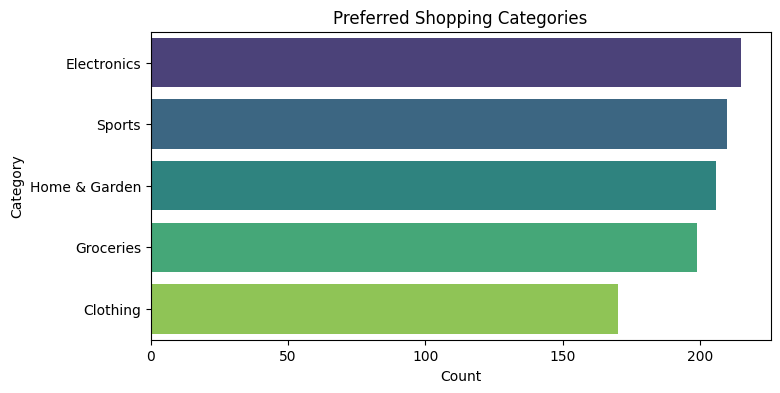

In [12]:
plt.figure(figsize=(8,4))
sns.countplot(y=df['preferred_category'], palette='viridis', order=df['preferred_category'].value_counts().index)
plt.title('Preferred Shopping Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_17628\4114417943.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['membership_years'], palette='coolwarm')


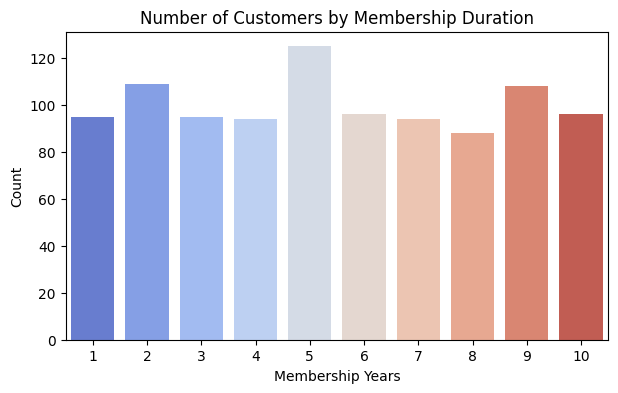

In [13]:
plt.figure(figsize=(7,4))
sns.countplot(x=df['membership_years'], palette='coolwarm')
plt.title('Number of Customers by Membership Duration')
plt.xlabel('Membership Years')
plt.ylabel('Count')
plt.show()


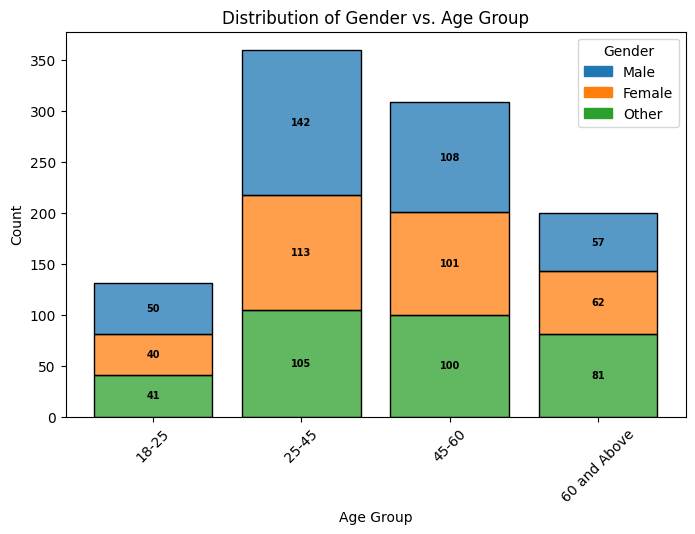

In [14]:
plt.figure(figsize=(8, 5))

# Define explicit colors for gender categories
gender_order = ["Male", "Female", "Other"]  # Define the correct order
palette = {"Male": "#1f77b4", "Female": "#ff7f0e", "Other": "#2ca02c"}  # Custom colors

# Create the stacked bar chart
ax = sns.histplot(
    data=df,
    x="age_group",
    hue="gender",
    multiple="stack",
    shrink=0.8,
    hue_order=gender_order,  # Ensure correct order
    palette=palette,  # Set colors explicitly
)


# Fix the legend manually
import matplotlib.patches as mpatches

legend_patches = [mpatches.Patch(color=palette[g], label=g) for g in gender_order]
plt.legend(handles=legend_patches, title="Gender", loc="upper right")


# Set title and labels
plt.title("Distribution of Gender vs. Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)

# -------- Adding Count Labels to Stacked Bars --------
for p in ax.patches:
    if p.get_height() > 0:  # Only label bars that have height
        ax.text(
            p.get_x() + p.get_width() / 2,  # X position (center of the bar)
            p.get_y() + p.get_height() / 2,  # Y position (middle of the segment)
            int(p.get_height()),  # Display the height as count
            ha="center",
            va="center",
            fontsize=7,
            color="black",
            fontweight="bold",
        )

plt.show()

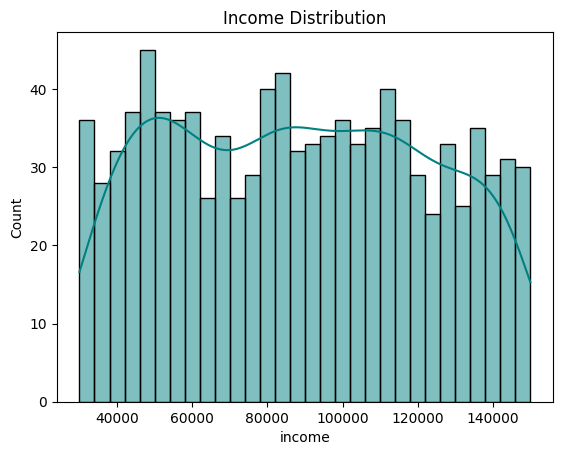

In [15]:
sns.histplot(df['income'], bins=30,kde= True , color='teal')
plt.title('Income Distribution')
plt.show()

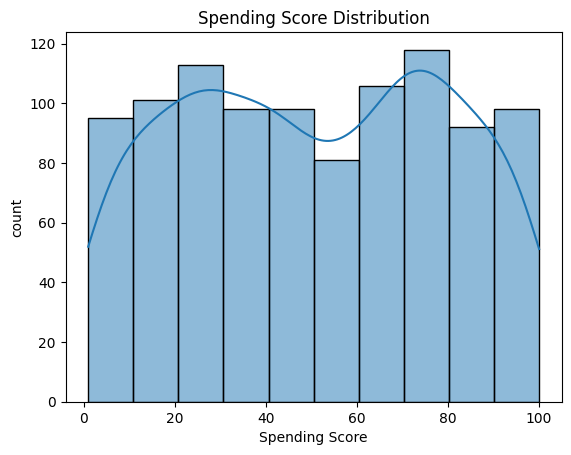

In [16]:
import seaborn as sns

sns.histplot(df['spending_score'], bins=10,kde=True, edgecolor='black')  # You can adjust the number of bins
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')  # Label for x-axis
plt.ylabel('count')  # Label for y-axis
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_17628\3817098317.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='spending_score', data=df, palette='viridis')


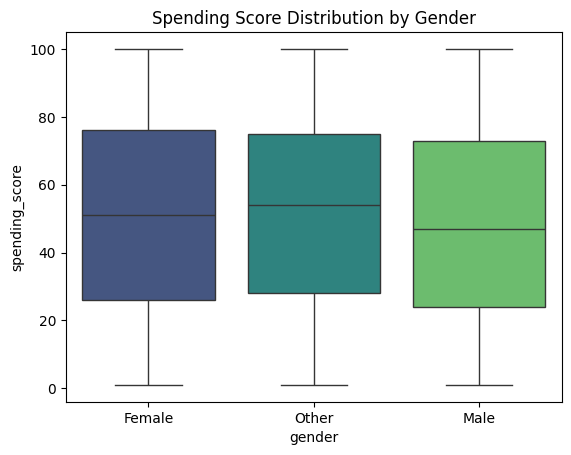

In [17]:
sns.boxplot(x='gender', y='spending_score', data=df, palette='viridis')
plt.title('Spending Score Distribution by Gender')
plt.show()



C:\Users\Hp\AppData\Local\Temp\ipykernel_17628\3191030367.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='spending_score', data=df, palette='viridis')


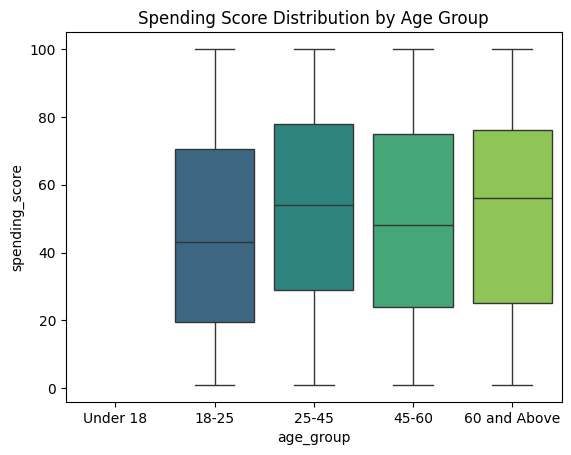

In [18]:
sns.boxplot(x='age_group', y='spending_score', data=df, palette='viridis')
plt.title('Spending Score Distribution by Age Group')
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_17628\3811871532.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='income', data=df, palette='coolwarm')


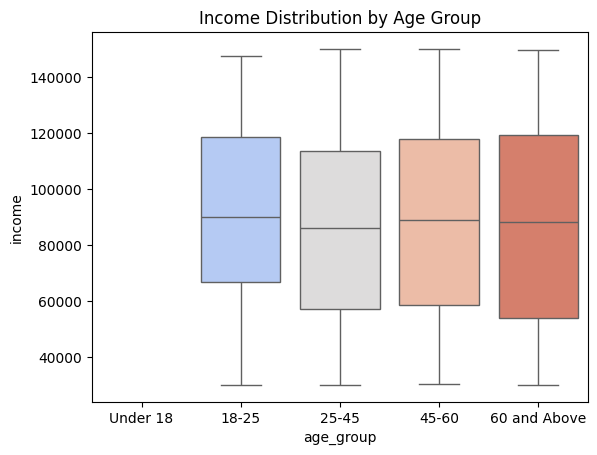

In [19]:
sns.boxplot(x='age_group', y='income', data=df, palette='coolwarm')
plt.title('Income Distribution by Age Group')
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_17628\3825057667.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='preferred_category', y='spending_score', data=df, palette='pastel')


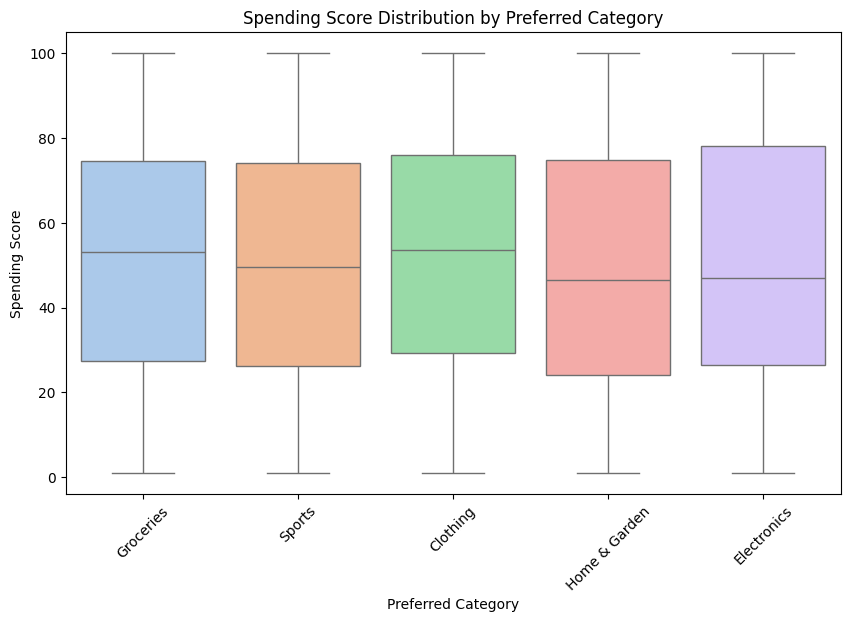

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='preferred_category', y='spending_score', data=df, palette='pastel')
plt.title('Spending Score Distribution by Preferred Category')
plt.xlabel('Preferred Category')
plt.ylabel('Spending Score')
plt.xticks(rotation=45)
plt.show()

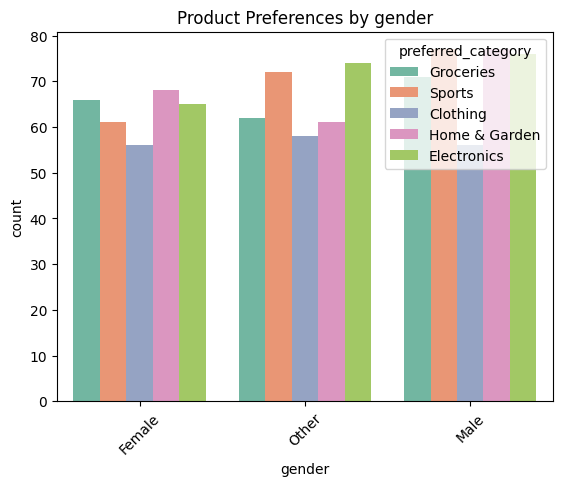

In [21]:
sns.countplot(data=df, x="gender", hue="preferred_category", palette="Set2")
plt.title("Product Preferences by gender")
plt.xticks(rotation=45)
plt.show()

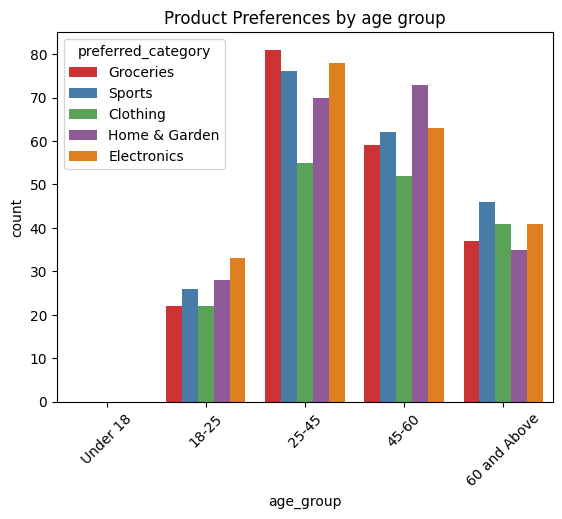

In [22]:
sns.countplot(data=df, x="age_group", hue="preferred_category", palette="Set1")
plt.title("Product Preferences by age group")
plt.xticks(rotation=45)
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_17628\2292800700.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='purchase_frequency', data=df, estimator=np.mean ,palette='Set1')


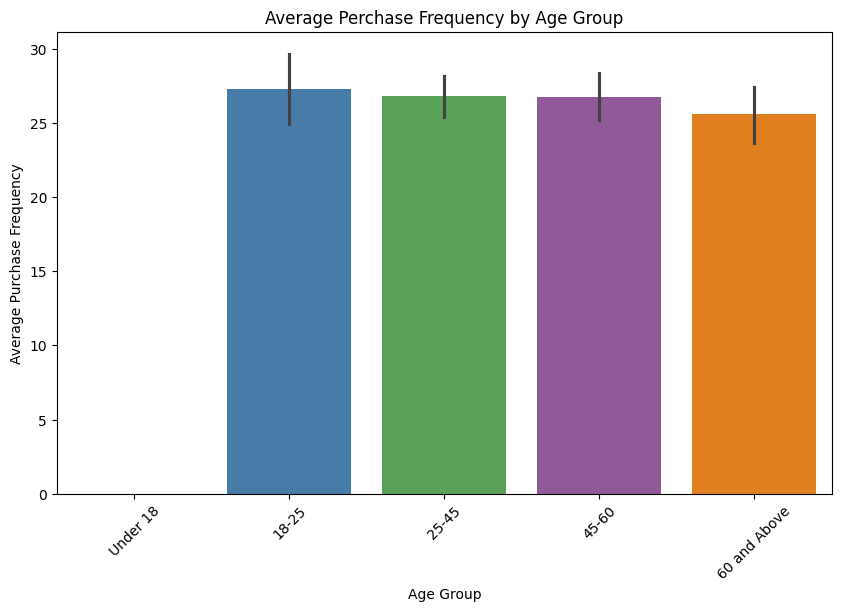

In [23]:
import numpy as np
plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='purchase_frequency', data=df, estimator=np.mean ,palette='Set1')
plt.title('Average Perchase Frequency by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Purchase Frequency')
plt.xticks(rotation=45)
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_17628\2785606160.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='last_purchase_amount', data=df, estimator=np.mean , palette= 'Set1')


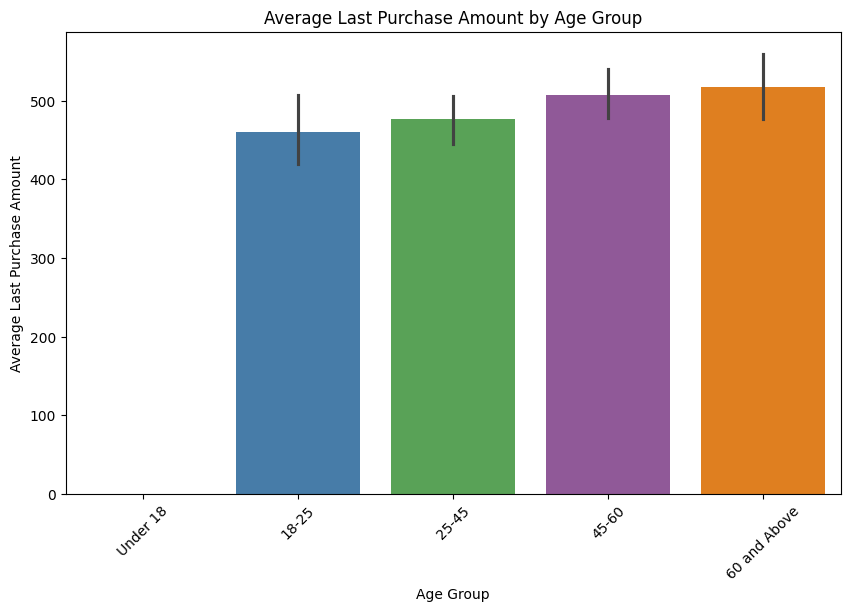

In [24]:
import numpy as np
plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='last_purchase_amount', data=df, estimator=np.mean , palette= 'Set1')
plt.title('Average Last Purchase Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Last Purchase Amount')
plt.xticks(rotation=45)
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_17628\481625358.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gender', y='purchase_frequency', data=df, estimator=np.mean,palette='Set1')


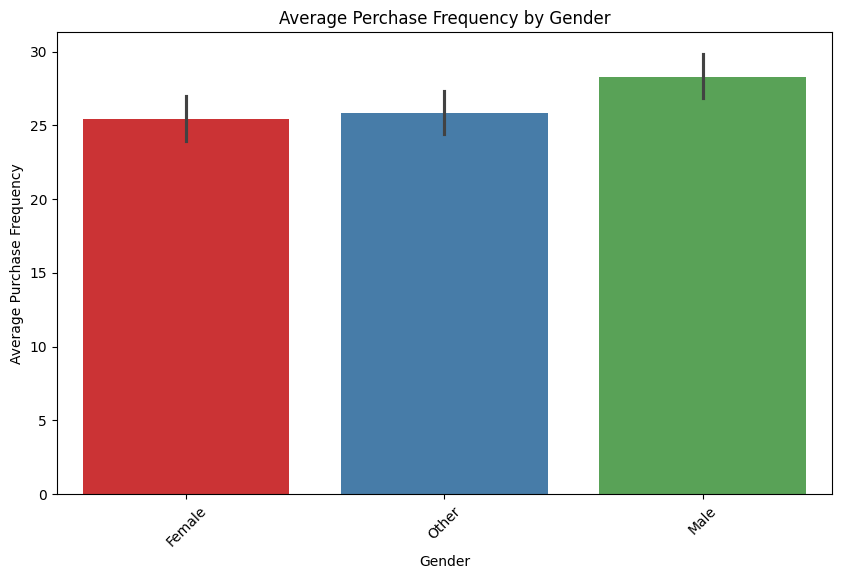

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(x='gender', y='purchase_frequency', data=df, estimator=np.mean,palette='Set1')
plt.title('Average Perchase Frequency by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Purchase Frequency')
plt.xticks(rotation=45)
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_17628\1491024499.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='preferred_category', y='purchase_frequency', data=df, estimator=np.mean,palette='Set1')


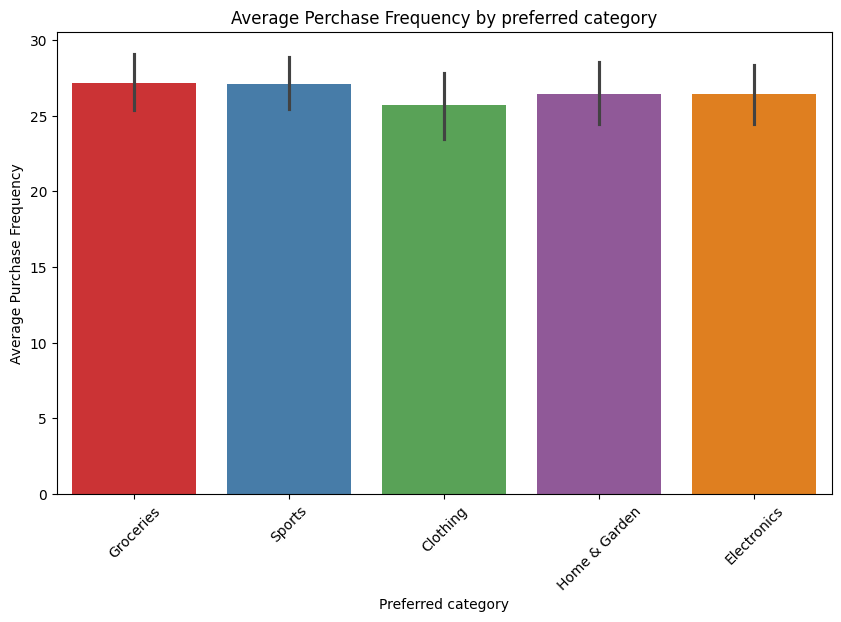

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x='preferred_category', y='purchase_frequency', data=df, estimator=np.mean,palette='Set1')
plt.title('Average Perchase Frequency by preferred category')
plt.xlabel('Preferred category')
plt.ylabel('Average Purchase Frequency')
plt.xticks(rotation=45)
plt.show()

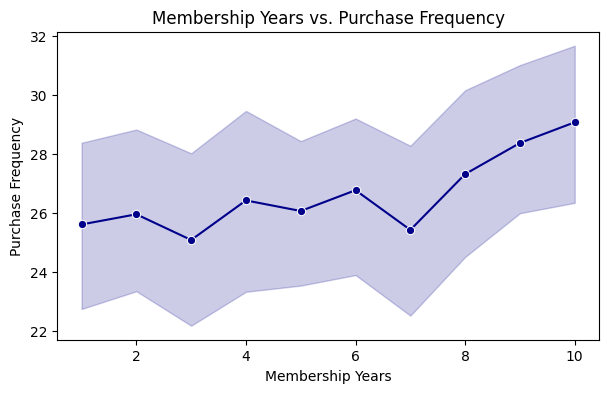

In [27]:
plt.figure(figsize=(7,4))
sns.lineplot(x='membership_years', y='purchase_frequency', data=df, marker='o', color='darkblue')
plt.title('Membership Years vs. Purchase Frequency')
plt.xlabel('Membership Years')
plt.ylabel('Purchase Frequency')
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_17628\1666127550.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='membership_years', y='spending_score', data=df,palette='Set1')


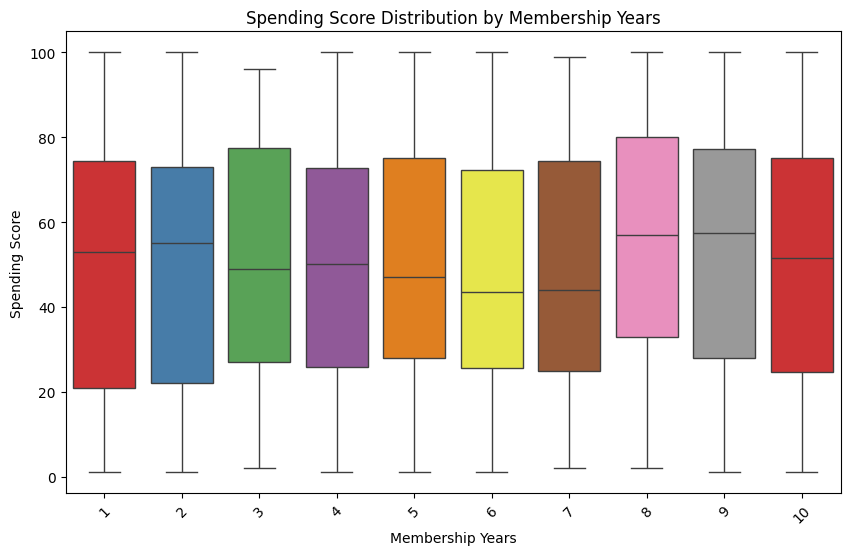

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='membership_years', y='spending_score', data=df,palette='Set1')
plt.title('Spending Score Distribution by Membership Years')
plt.xlabel('Membership Years')
plt.ylabel('Spending Score')
plt.xticks(rotation=45)
plt.show()


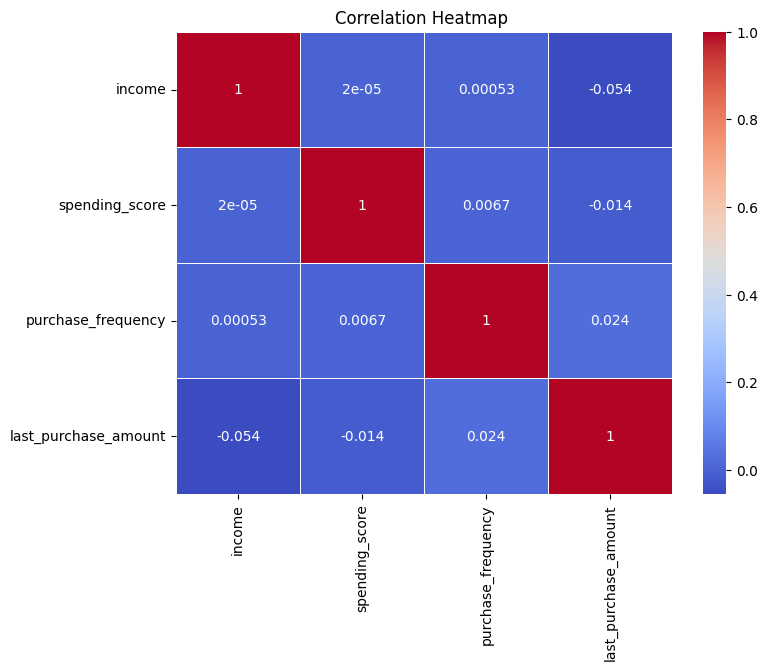

In [29]:
corr_matrix = df[['income', 'spending_score', 'purchase_frequency', 'last_purchase_amount']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap ')
plt.show()


In [30]:
df2=df.copy()
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.preprocessing import LabelEncoder

# Label Encoding for binary categorical features
le = LabelEncoder()
df2['age_group'] = le.fit_transform(df2['age_group'])  
# One-Hot Encoding for categorical columns
df2=pd.get_dummies(df2, columns=['preferred_category','gender'])
scaler = StandardScaler()
columns_to_scale = ['income','spending_score','membership_years','purchase_frequency','last_purchase_amount']

df2[columns_to_scale] = scaler.fit_transform(df2[columns_to_scale])

# Check processed data
df2.head()




,income,spending_score,membership_years,purchase_frequency,last_purchase_amount,age_group,preferred_category_Clothing,preferred_category_Electronics,preferred_category_Groceries,preferred_category_Home & Garden,preferred_category_Sports,gender_Female,gender_Male,gender_Other
0,0.316868,1.358468,-0.865010,-0.182348,-1.281540,1,False,False,True,False,False,True,False,False
1,-0.282016,0.321865,-1.215358,1.082005,-1.523763,0,False,False,False,False,True,True,False,False
2,1.112778,-0.714738,-1.215358,0.098620,-0.230005,3,True,False,False,False,False,True,False,False
3,-1.210096,0.805613,1.237080,-1.516943,1.690080,1,False,False,False,True,False,False,False,True
4,1.523374,-1.025718,-0.865010,-0.112106,-0.491443,3,False,True,False,False,False,True,False,False


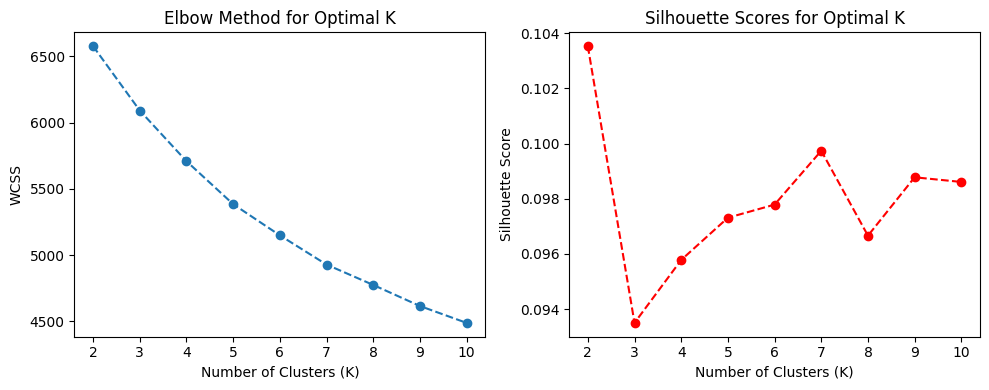

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Finding the optimal K using Elbow Method
wcss = []
silhouette_scores = []
K_range = range(2, 11)  # Checking clusters from 2 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df2)
    
    # Within-Cluster Sum of Squares (WCSS)
    wcss.append(kmeans.inertia_)
    
    # Silhouette Score
    silhouette_scores.append(silhouette_score(df2, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')


# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', linestyle='--', color='red')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Optimal K')

columns_to_use = ['income', 'spending_score', 'membership_years', 'purchase_frequency', 
                  'last_purchase_amount', 'age_group'] + list(df2.filter(like='preferred_category_')) + list(df2.filter(like='gender_'))

df_scaled_fixed = df2[columns_to_use]

plt.tight_layout()
plt.show()

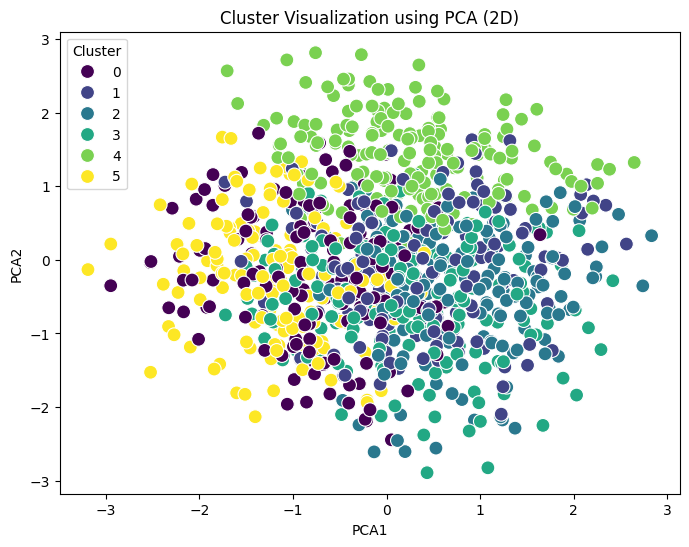

In [32]:
columns_to_use = ['income', 'spending_score', 'membership_years', 'purchase_frequency', 
                  'last_purchase_amount', 'age_group'] + list(df2.filter(like='preferred_category_')) + list(df2.filter(like='gender_'))

df_scaled_fixed = df2[columns_to_use]

optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
df2['Cluster'] = kmeans.fit_predict(df_scaled_fixed)
df2['Cluster'].value_counts()

pca = PCA(n_components=2, random_state=42)  # Set random state for consistency
pca_transformed = pca.fit_transform(df_scaled_fixed)

df2['PCA1'] = pca_transformed[:, 0]
df2['PCA2'] = pca_transformed[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df2, x='PCA1', y='PCA2', hue=df2['Cluster'], palette='viridis', s=100)
plt.title('Cluster Visualization using PCA (2D)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Cluster')
plt.show()


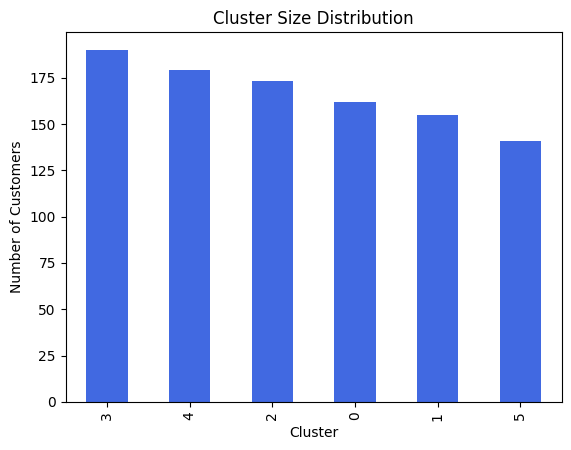

In [33]:
df2['Cluster'].value_counts().plot(kind='bar', color='royalblue')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Cluster Size Distribution')
plt.show()


In [34]:
cluster_summary = df2.groupby("Cluster").mean()

# View cluster characteristics
cluster_summary
cluster_means=pd.DataFrame(cluster_summary)
cluster_means



,income,spending_score,membership_years,purchase_frequency,last_purchase_amount,age_group,preferred_category_Clothing,preferred_category_Electronics,preferred_category_Groceries,preferred_category_Home & Garden,preferred_category_Sports,gender_Female,gender_Male,gender_Other,PCA1,PCA2
Cluster,,,,,,,,,,,,,,,,
0,0.436187,-0.758249,-0.577378,-0.097364,-0.021208,0.555556,0.117284,0.228395,0.185185,0.259259,0.209877,0.271605,0.475309,0.253086,-0.711303,-0.205885
1,-0.400528,-1.009222,0.812141,0.041067,-0.526253,1.922581,0.200000,0.219355,0.180645,0.154839,0.245161,0.283871,0.361290,0.354839,0.374206,-0.122179
2,0.746578,0.486443,0.848254,0.512356,0.667709,1.543353,0.156069,0.225434,0.242775,0.196532,0.179191,0.300578,0.346821,0.352601,0.797016,-0.343179
3,-0.672148,0.879266,0.139937,-0.098058,-0.740226,1.210526,0.184211,0.189474,0.221053,0.194737,0.210526,0.452632,0.352632,0.194737,0.225274,-0.570845
4,-0.843765,-0.026372,-0.510747,-0.079143,1.014224,2.039106,0.189944,0.229050,0.167598,0.212291,0.201117,0.251397,0.273743,0.474860,0.261174,1.420475
5,1.000026,0.232418,-0.810346,-0.329308,-0.506467,2.326241,0.170213,0.198582,0.191489,0.219858,0.219858,0.319149,0.340426,0.340426,-1.207139,-0.242151


C:\Users\Hp\AppData\Local\Temp\ipykernel_17628\2074989696.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=df2, palette='viridis')
C:\Users\Hp\AppData\Local\Temp\ipykernel_17628\2074989696.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=df2, palette='viridis')
C:\Users\Hp\AppData\Local\Temp\ipykernel_17628\2074989696.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=df2, palette='viridis')
C:\Users\Hp\AppData\Local\Temp\ipykernel_17628\2074989696.

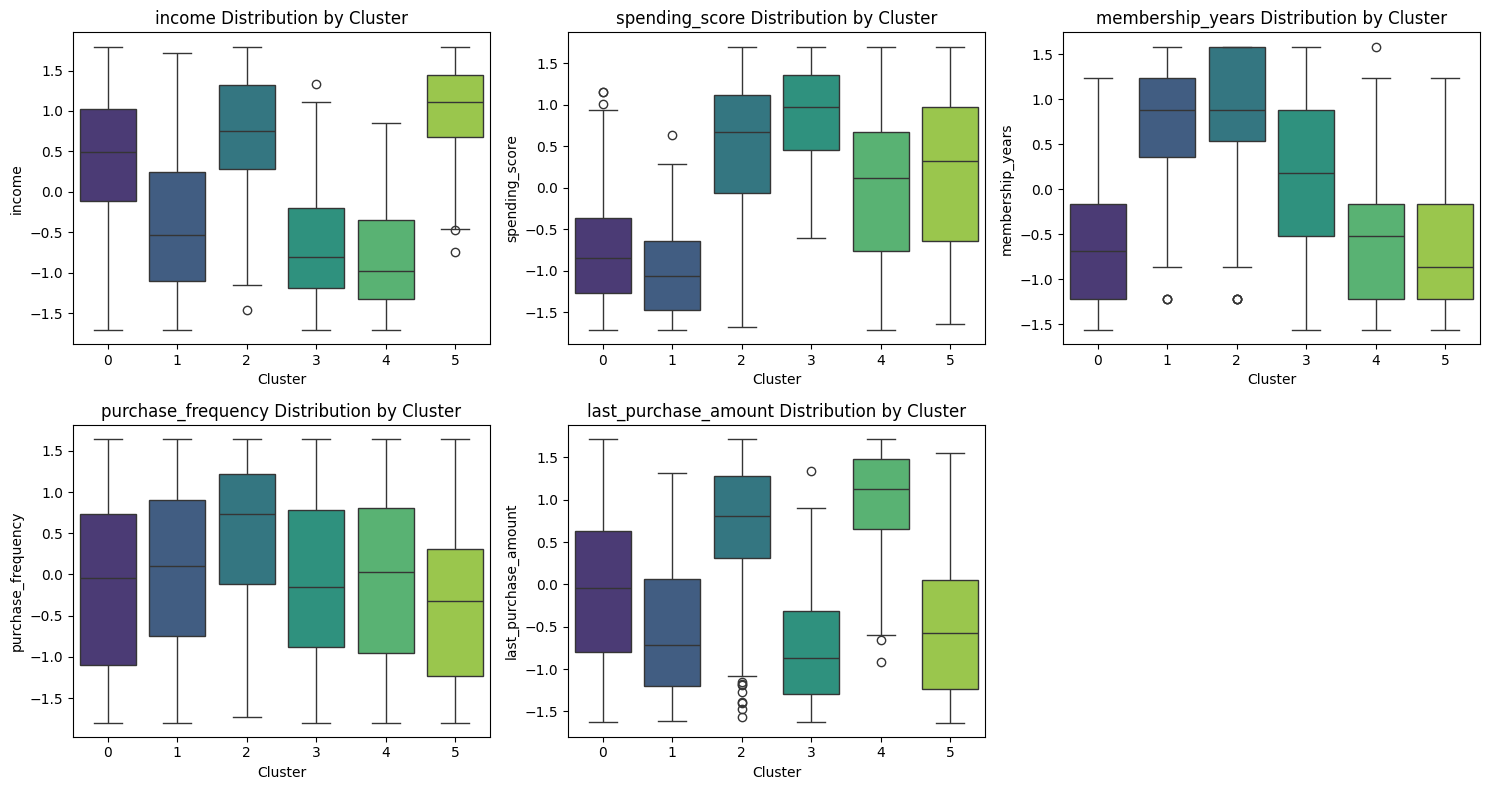

In [35]:
features = ['income', 'spending_score', 'membership_years', 'purchase_frequency', 'last_purchase_amount']

plt.figure(figsize=(15, 8))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Cluster', y=feature, data=df2, palette='viridis')
    plt.title(f'{feature} Distribution by Cluster')

plt.tight_layout()
plt.show()


In [36]:

def label_clusters(df_cluster, df2):
    cluster_labels = {}

    preferred_category_cols = [col for col in df2.columns if col.startswith('preferred_category_')]
    gender_cols = [col for col in df2.columns if col.startswith('gender_')]

    used_labels = set()

    for cluster in df_cluster.index:
        row = df_cluster.loc[cluster]
        label_parts = []

        income = row['income']
        spending = row['spending_score']
        freq = row['purchase_frequency']
        last_amt = row['last_purchase_amount']
        age = row['age_group']

        # === Descriptive parts ===
        if income > 0.7:
            label_parts.append("High-Income")
        elif income < -0.6:
            label_parts.append("Low-Income")

        if spending > 0.5:
            label_parts.append("High Spenders")
        elif spending < -0.5:
            label_parts.append("Low Spenders")

        if freq > 0.5:
            label_parts.append("Frequent Shoppers")
        if last_amt > 0.6:
            label_parts.append("Big Spenders")

        if age > 1.5:
            label_parts.append("Older Consumers")
        elif age < 0.6:
            label_parts.append("Young Shoppers")

        preferred_category = "Unknown"
        if preferred_category_cols:
            try:
                preferred_category = df_cluster.loc[cluster, preferred_category_cols].idxmax().replace('preferred_category_', '')
                if df_cluster.loc[cluster, f'preferred_category_{preferred_category}'] > 0.2:
                    label_parts.append(f"Prefer {preferred_category}")
            except Exception:
                pass

        gender = "Unknown"
        if gender_cols:
            try:
                gender = df_cluster.loc[cluster, gender_cols].idxmax().replace('gender_', '')
                if df_cluster.loc[cluster, f'gender_{gender}'] > 0.4:
                    label_parts.append(f"Mostly {gender}")
            except Exception:
                pass

        # === Smart Short Label Generator ===
        if income > 0.7 and spending > 0.5 and freq > 0.5:
            short_label = "Elite High-Spenders"
        elif income < -0.6 and spending > 0.7:
            short_label = "Budget Luxury Shoppers"
        elif age > 1.5 and last_amt > 0.6:
            short_label = "Senior Premium Buyers"
        elif age < 0.6 and spending < -0.5:
            short_label = "Young Budget Shoppers"
        elif preferred_category == "Clothing" and gender == "Female":
            short_label = "Fashion-Forward Women"
        elif preferred_category == "Electronics" and income < -0.4 and spending > 0.5:
            short_label = "Value-Driven Tech Spenders"
        elif preferred_category == "Sports" and age > 1.5 and spending < -0.4:
            short_label = "Older Budget Sport Enthusiasts"
        elif preferred_category == "Home & Garden" and income > 0.6:
            short_label = "Affluent Home Improvers"
        elif preferred_category == "Groceries" and age > 1.5:
            short_label = "Daily Senior Essentials Buyers"
        else:
            # Fallback smart label
            short_label = f"{preferred_category} Focused {gender}".title().replace("Unknown", "").strip()
            if not short_label:
                short_label = "Diverse Shopper Group"

        # Ensure uniqueness
        if short_label in used_labels:
            suffix = 1
            new_label = f"{short_label} {suffix}"
            while new_label in used_labels:
                suffix += 1
                new_label = f"{short_label} {suffix}"
            short_label = new_label

        used_labels.add(short_label)
        
        cluster_labels[cluster] = {
            'label': short_label,
            'description': " & ".join(label_parts) if label_parts else "General Shoppers"
        }

    return cluster_labels
cluster_labels = label_clusters(cluster_means, df2)

for cluster, info in cluster_labels.items():
    print(f"Cluster {cluster}:")
    print(f"  Short Label: {info['label']}")
    print(f"  Description: {info['description']}")
    print()

Cluster 0:
  Short Label: Young Budget Shoppers
  Description: Low Spenders & Young Shoppers & Prefer Home & Garden & Mostly Male

Cluster 1:
  Short Label: Older Budget Sport Enthusiasts
  Description: Low Spenders & Older Consumers & Prefer Sports

Cluster 2:
  Short Label: Senior Premium Buyers
  Description: High-Income & Frequent Shoppers & Big Spenders & Older Consumers & Prefer Groceries

Cluster 3:
  Short Label: Budget Luxury Shoppers
  Description: Low-Income & High Spenders & Prefer Groceries & Mostly Female

Cluster 4:
  Short Label: Senior Premium Buyers 1
  Description: Low-Income & Big Spenders & Older Consumers & Prefer Electronics & Mostly Other

Cluster 5:
  Short Label: Affluent Home Improvers
  Description: High-Income & Older Consumers & Prefer Home & Garden



In [37]:
df2.to_csv(r"C:\\Users\\Hp\\Desktop\\major project\\df_enco")

cluster_means.to_csv(r"C:\\Users\\Hp\\Desktop\\major project\\clus_mean")

